# Greenback — a quantitative teardown 🔬
### The carry premium by bucket · three sleeves · the combo's Sharpe uplift · the leg correlation · the negative-skew crash

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: FX carry is a real premium (§8.3/§8.4 of Kakushadze-Serur), and the **carry⊕momentum combo** beats either leg because the two decorrelate. We confirm carry is `REAL` (high-minus-low +5.3%/yr, Sharpe +1.18, null flat), that it carries the `FRAGILE` steamroller (skew −1.55, DD −60%), and that the combo lifts the Sharpe to +1.69 while halving-plus the drawdown — building on Study 27 (Steamroller), not repeating it.

> ⚠️ **Not investment advice.** The core executes on a synthetic FX panel; the real G10 run is PENDING one FRED fetch in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from greenback import data, strategy, costs, extension

# Offline synthetic control: a currency panel with a carry premium + risk-off crashes + an independent
# trend for the momentum sleeve (the machinery) + a full-UIRP carry null. The real G10 verdict is PENDING
# one networked FRED fetch — see ../docs/results.md.
xr, rd, truth = data.synthetic_fx(carry_strength=0.9, trend_strength=0.35, seed=36)
x0, r0, _ = data.synthetic_fx(carry_strength=0.0, trend_strength=0.35, seed=36)
print(f"synthetic control: {truth.n_ccy} currencies x {truth.n_months} months, "
      f"carry_strength {truth.carry_strength} (null=0), trend_strength {truth.trend_strength}")


synthetic control: 9 currencies x 600 months, carry_strength 0.9 (null=0), trend_strength 0.35


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — carry & momentum real? | 🟢 `REAL` | High-minus-low **+5.3%/yr**, carry Sharpe **1.18**, momentum **1.53**; null flat (**+0.8%/yr**). |
| **Tradability** | 🟡 `FRAGILE` | Carry skew **-1.55**, DD **-60%**; the combo dulls it (**-60% → -20%**) but the jump remains. |
| **Real-tape run?** | ⚪ `Pre-reg` | Needs FRED short rates (time out here) — PENDING one fetch. |

> **In one sentence:** a real FX carry premium with a brutal negative-skew crash, *cushioned* (not removed) by blending in decorrelated momentum — the combo Sharpe **+1.69** beats either leg and the drawdown falls to **−20%**.

*(This notebook executes on the synthetic control; the real G10 numbers are PENDING in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Carry weight $w^{c}_{i,t}\propto \text{sign of rank}(r_{i}-\bar r)$ — long the top, short the bottom rate-differential quantile, dollar-neutral, lagged. Momentum weight $w^{m}_{i,t}\propto \text{rank of }\big(\prod_{k=1}^{12}(1+x_{i,t-k})-1\big)$. Both legs are vol-scaled to a common target, then the **combo** is $\tfrac12 c_t+\tfrac12 m_t$. Claim: $\text{Sharpe}(\text{combo})>\max(\text{Sharpe}(c),\text{Sharpe}(m))$ and $\text{corr}(c,m)$ is low. Null: full UIRP ⇒ no carry premium (the spot exactly offsets the rate gap).

In [2]:
for label, (xx, rr) in [('carry panel', (xr, rd)), ('null', (x0, r0))]:
    pb = strategy.carry_premium_by_bucket(xx, rr)
    s = strategy.summary(strategy.carry_returns(xx, rr, cost_bps=0.0, target_vol_ann=None))
    print(f"{label:12} high-minus-low {pb['hml_ann_pct']:+5.1f}%/yr   carry Sharpe {s['sharpe']:+.2f}   skew {s['skew']:+.2f}")

carry panel  high-minus-low  +5.3%/yr   carry Sharpe +0.62   skew -2.12


null         high-minus-low  +0.8%/yr   carry Sharpe +0.19   skew -0.00


> 💡 **In plain words.** When carry is real the high-rate bucket out-earns the low-rate bucket (**+5.3%/yr**) and the carry book makes money with a sharp negative skew; under full UIRP it's flat (**+0.8%/yr**). The apparatus sees carry only when it's there — so the real-tape result is about the *market*.

## Beat 2 · So what?

Lustig-Roussanov-Verdelhan (2011) show carry and the dollar factor are *priced* currency risk premia; Asness-Moskowitz-Pedersen (2013) and Koijen et al (2018) show carry/value and momentum are negatively correlated *everywhere*, so combining them is the single highest-Sharpe move in factor investing. The pre-registered prediction: the combo beats either leg and momentum leans *against* the carry crash. Beats 4-7 test that head-on.

## Beat 3 · Pre-registered protocol

1. **Real?** `carry_premium_by_bucket` + `carry_returns` (gross) on control vs null.
2. **Crash?** the carry book's `skew`, worst month, `max_drawdown` (`extension.carry_crash`).
3. **Combo?** `extension.diversification` — combo Sharpe vs legs, the leg correlation.
4. **Costs?** `costs.cost_sweep`, `costs.breakeven_cost_bps`.

**Mirage line:** combo fails to beat the better leg, or the legs are highly correlated — then the diversification story is a mirage.

## Beat 4 · The teardown

### 4a · The three sleeves (net @10 bp)

In [3]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)
mom   = strategy.momentum_returns(xr, cost_bps=10.0)
combo = strategy.combine(carry, mom)
dollar = strategy.dollar_carry_returns(xr, rd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', carry), ('dollar-carry', dollar), ('momentum', mom), ('COMBO', combo)]:
    s = strategy.summary(r)
    rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'vol%': s['vol_ann']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))

,Sharpe,ret%,vol%,skew,maxDD%
carry,1.180,10.440,8.880,-1.550,-60.210
dollar-carry,0.170,0.910,5.260,-0.130,-44.040
momentum,1.530,11.890,7.790,-0.360,-18.200
COMBO,1.690,11.170,6.630,-1.620,-20.250


> 💡 **In plain words.** Carry and momentum both earn — but carry crashes (skew −1.55, DD −60%) and momentum doesn't (DD −18%). The dollar-carry tilt is weak *on this synthetic* because the average rate gap is near-constant by construction; on the real tape, where the USD rate cycles, it's a genuine separate premium (that's what `--fetch` measures).

### 4b · The combo beats the legs, and the legs decorrelate (the REAL diversification call)

carry Sharpe +1.18  momentum +1.53  combo +1.69
combo beats both legs: True   carry-momentum correlation +0.26


Text(0.5, 1.0, 'Equal-risk carry+momentum combo grows steadier than either leg')

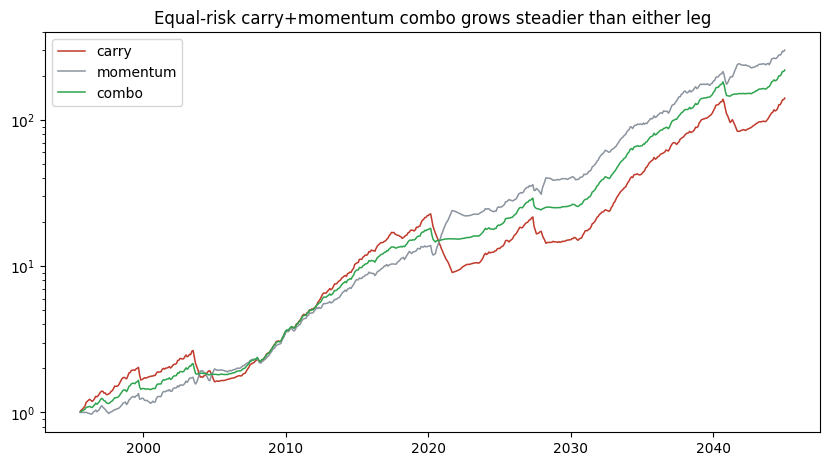

In [4]:
d = extension.diversification(xr, rd, cost_bps=10.0)
print(f"carry Sharpe {d['carry_sharpe']:+.2f}  momentum {d['momentum_sharpe']:+.2f}  combo {d['combo_sharpe']:+.2f}")
print(f"combo beats both legs: {d['combo_beats_legs']}   carry-momentum correlation {d['leg_correlation']:+.2f}")
fig, ax = plt.subplots()
for nm, r, c in [('carry', carry, '#c0392b'), ('momentum', mom, '#8b949e'), ('combo', combo, '#2ea44f')]:
    ax.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
ax.legend(); ax.set_yscale('log'); ax.set_title('Equal-risk carry+momentum combo grows steadier than either leg')

### 4c · The steamroller, and how momentum cushions it (the FRAGILE call)

carry: skew -1.55, worst month -13.7%, max DD -60%
combo: skew -1.62, worst month -11.3%, max DD -20%
in carry's worst 5 months, combo lost -9.3% vs carry -11.0%


Text(0.5, 1.0, 'Drawdown: the combo (green) is dragged far less deep into the steamroller')

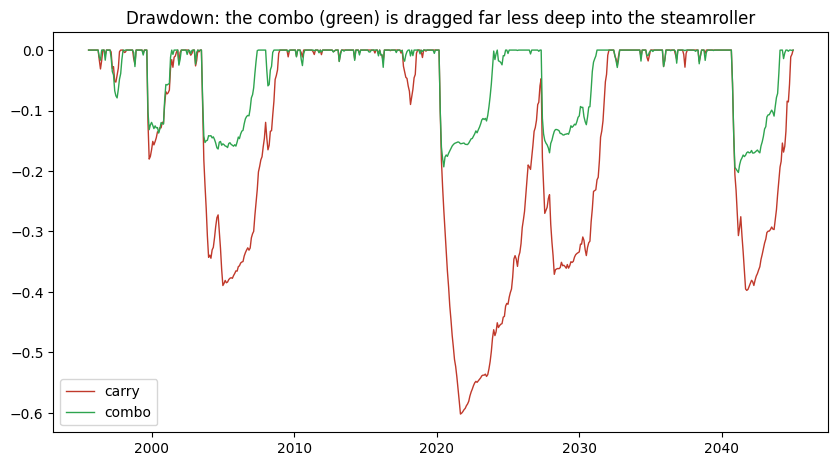

In [5]:
cc = extension.carry_crash(xr, rd, cost_bps=10.0)
print(f"carry: skew {cc['carry_skew']:+.2f}, worst month {cc['carry_worst_month_pct']:+.1f}%, max DD {cc['carry_max_dd_pct']:.0f}%")
print(f"combo: skew {cc['combo_skew']:+.2f}, worst month {cc['combo_worst_month_pct']:+.1f}%, max DD {cc['combo_max_dd_pct']:.0f}%")
print(f"in carry's worst 5 months, combo lost {cc['combo_in_carry_worst5_pct']:+.1f}% vs carry {cc['carry_worst5_mean_pct']:+.1f}%")
fig, ax = plt.subplots()
for nm, r, c in [('carry', carry, '#c0392b'), ('combo', combo, '#2ea44f')]:
    eq = (1+r).cumprod(); ax.plot(eq/eq.cummax()-1, label=nm, color=c, lw=1.0)
ax.legend(); ax.set_title('Drawdown: the combo (green) is dragged far less deep into the steamroller')

> 💡 **In plain words.** Diversification is the honest fix Study 27's vol-overlay couldn't provide: momentum is leaning *against* the crashing carry trade, so the combo's drawdown is **-20%** versus carry's **-60%**. But the combo's skew is still negative — the jump is *dulled*, not gone. That's exactly why tradability is `FRAGILE`.

## Beat 5 · The verdict

- **`REAL`** (4a/4b): high-minus-low +5.3%/yr, carry Sharpe 1.18, combo 1.69; null flat.
- **`FRAGILE`** (4c): carry skew -1.55, DD -60%; combo dulls to -20% but keeps a negative skew.
- **Real-tape run? `PRE-REG`**: PENDING one FRED fetch.

> **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`** — the dollar-carry / carry⊕momentum-combo companion to Study 27.

## Beat 6 · Could you trade it?

- **Cheap to run.** Carry turns over slowly; momentum's break-even is ≈14.6 bp; the combo's Sharpe decays gently (1.75 → 1.13 from 0 to 100 bp).
- **The binding risk is the crash, not the cost or the capacity** (G10 FX is the deepest market on earth). Even diversified, the combo keeps negative skew.
- **The real fragility line** (real tape): a 2008-style crash deepening rather than dulling — tested the moment `--fetch` runs.

## Beat 7 · Going further

### 7a · Worked complement — the carry⊕momentum diversification ([`../docs/extension.md`](../docs/extension.md))
The cost sweep below confirms the combo survives realistic costs; the diversification itself (beats 4b/4c) is the complement. Real-tape version PENDING `--fetch`.

,sharpe,ann_return
cost_bps,,
0,1.746,0.116
10,1.685,0.112
25,1.593,0.106
50,1.440,0.096
100,1.134,0.077


momentum break-even: 14.6 bp


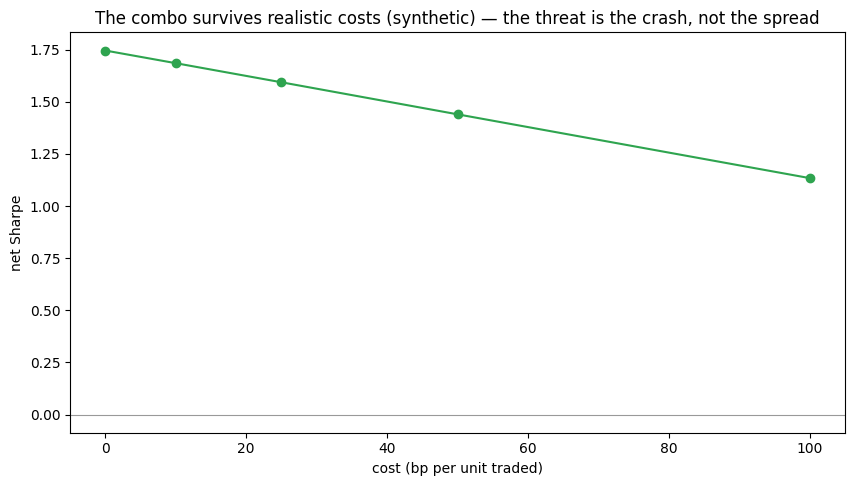

In [6]:
cs = costs.cost_sweep(xr, rd, which='combo')
display(cs.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#2ea44f')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('The combo survives realistic costs (synthetic) — the threat is the crash, not the spread')
print('momentum break-even:', round(costs.breakeven_cost_bps(xr, rd, which='momentum'), 1), 'bp')

### 7b · Other forks
- **Optimal combo weight** — sweep `w_carry`, risk-parity vs the realised crisis correlation.
- **Dollar-carry as a third leg** — add the LRV dollar factor (real tape, where the USD rate cycles).
- **Crisis-conditional tilt** — lean toward momentum when global FX vol (Brunnermeier-Nagel-Pedersen) is rising.

**The result.** On the synthetic control the carry premium is `REAL` and recovered, the steamroller is present, and the carry⊕momentum combo `FRAGILE`-but-better lifts the Sharpe and cushions the crash — exactly the §8.3/§8.4 thesis, building on Study 27. The fingerprinted real G10 verdict is **PENDING** one `examples/verify.py --fetch`; full writeups in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).